# BC Regular vs BC CIRL vs CQL Regular vs CQL CIRL — offline policy comparison

Extends `BC_vs_CQL_Offline_Policy_Comparison.ipynb` (which only compared the two
**CIRL** actors) to all **four** offline policies trained in Phases 1-2, each
evaluated **zero-shot on Juan's 4 new days** (16-19 June 2026), with no
gradient updates and no plant interaction — the same setting the Phase 3
warm-start comparison and Phase 4 fine-tuning both start from.

| Policy | Checkpoint | Predicts | Control law |
|---|---|---|---|
| **BC Regular**  | `bc_regular_anti_windup_best.pt`  | flow `q` directly (10-D state, incl. `q_prev`) | `q = clip(q_raw, q_min, q_max)`, fixed expert anti-windup `Kw` |
| **BC CIRL**     | `bc_cirl_setpoint_anti_windup_best.pt` | PI gains `[Kp,Ki,Kw]` (9-D state) | `q = clip(Kp*e + Ki*I_e, q_min, q_max)`, `Kw` pinned to `Ki/Kp` |
| **CQL Regular** | `cql_regular_anti_windup_best.pt` | flow `q` directly (10-D state, incl. `q_prev`) | `q = clip(q_raw, q_min, q_max)`, fixed expert anti-windup `Kw` |
| **CQL CIRL**    | `cql_cirl_actor_best.pt` | PI gains `[Kp,Ki,Kw]` (9-D state) | `q = clip(Kp*e + Ki*I_e, q_min, q_max)`, `Kw` learned |

Both Regular policies use the same fixed back-calculation anti-windup constant
as the expert PI (`Kw = Ki_expert/Kp_expert`), since a free-form flow policy has
no gain output of its own to learn one from.

In [1]:
# ── Setup: shared library + this folder's (CIRL/gain-box) config ────────────────
import os, sys
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import torch
sys.path.insert(0, os.getcwd())
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), os.pardir)))  # main_script
from main_script import *
import config as cfg
from config import *
configure(cfg)

# Checkpoints — all four live in this folder's policies/ dir
BC_REG_CKPT  = 'bc_regular_anti_windup_best.pt'
BC_CIRL_CKPT = 'bc_cirl_setpoint_anti_windup_best.pt'
CQL_REG_CKPT = 'cql_regular_anti_windup_best.pt'
CQL_CIRL_CKPT = 'cql_cirl_actor_best.pt'

# CIRL gain boxes [Kp, Ki, Kw] — native to each trained CIRL policy
BC_LOW    = np.array([-0.625, -0.625/300, 1.0/300], np.float32)   # Kw pinned to expert Ki/Kp
BC_HIGH   = np.array([-0.375, -0.125/300, 1.0/300], np.float32)
CQL_LOW   = np.array([-3.5,  -0.060, -0.35], np.float32)
CQL_HIGH  = np.array([-0.1,  -0.0002, 0.05], np.float32)

# Regular actors use a 10-D state (adds q_prev) with their own obs box —
# independent of this folder's 9-D gain-box config, so normalised locally.
REG_OBS_LOW  = np.array([ 30.0, -40.0, -40000.0, -5.0,    0.0,  0.0, 10.0,   0.0, Q_MIN, 55.0], np.float32)
REG_OBS_HIGH = np.array([100.0,  55.0,  40000.0,  5.0, 1200.0, 50.0, 90.0, 180.0, Q_MAX, 85.0], np.float32)
def normalize_obs_10d(state):
    return (state - REG_OBS_LOW) / (REG_OBS_HIGH - REG_OBS_LOW + 1e-8)

datasets = [load_dataset(f) for f in JUAN_FILES]
print("Setup complete; evaluating on", len(datasets), "Juan days:", [d['name'] for d in datasets])

Setup complete; evaluating on 4 Juan days: ['16_06_2026__Sunny_Closed_Loop.xlsx', '17_06_2026__Sunny_Closed_Loop.xlsx', '18_06_2026__Sunny_Closed_Loop.xlsx', '19_06_2026__Sunny_Closed_Loop.xlsx']


In [2]:
# ── Load the four offline policies ────────────────────────────────────────
def load_gain_policy(ckpt):
    a = GainActor(in_dim=9, out_dim=3).to(DEVICE)
    a.load_state_dict(torch.load(os.path.join(SAVE_DIR, ckpt), map_location=DEVICE, weights_only=True))
    a.eval(); return a

def load_flow_policy(ckpt):
    a = FlowActor(in_dim=10, q_min=Q_MIN, q_max=Q_MAX).to(DEVICE)
    a.load_state_dict(torch.load(os.path.join(SAVE_DIR, ckpt), map_location=DEVICE, weights_only=True))
    a.eval(); return a

bc_reg_pol  = load_flow_policy(BC_REG_CKPT)
bc_cirl_pol = load_gain_policy(BC_CIRL_CKPT)
cql_reg_pol = load_flow_policy(CQL_REG_CKPT)
cql_cirl_pol = load_gain_policy(CQL_CIRL_CKPT)
print("Loaded BC Regular, BC CIRL, CQL Regular, CQL CIRL.")

# ── Rollout helpers ────────────────────────────────────────────────────────
def rollout_gains(actor, data, glow, ghigh):
    """CIRL gain policy: state -> [Kp,Ki,Kw] -> q = clip(Kp*e + Ki*I_e)."""
    tref = dataset_tref(data['name'])
    Tin=data['Tin']; I=data['I_sol']; Ta=data['Ta']; th=data['theta']; T_sc=data['T_sc']; qm=data['q']; N=data['N']
    tout=float(T_sc[0]); tout_prev=tout; q_prev=float(qm[0]); int_e=None
    T=[]; Q=[]
    with torch.no_grad():
        for t in range(N-1):
            e=tref-tout; de=-(tout-tout_prev)/TS
            ie = 0.0 if int_e is None else int_e
            state=np.array([tout,e,ie,de,I[t],Ta[t],Tin[t],th[t],tref],np.float32)
            s=torch.from_numpy(normalize_obs(state).reshape(1,-1))
            g=np.clip(actor(s).cpu().numpy()[0],0,1)*(ghigh-glow+1e-8)+glow
            Kp,Ki,Kw=g
            if int_e is None:   # bumpless preload with the policy's own gains
                int_e=float(np.clip((q_prev - Kp*e)/Ki, -INT_E_CLIP, INT_E_CLIP))
            q_raw=Kp*e+Ki*int_e
            q=float(np.clip(q_raw,Q_MIN,Q_MAX))
            tn=solar_model(q,Tin[t],I[t],Ta[t],th[t],tout)
            T.append(tn); Q.append(q)
            int_e=float(np.clip(int_e+(e+Kw*(q-q_raw))*TS,-INT_E_CLIP,INT_E_CLIP))
            tout_prev=tout; tout=tn; q_prev=q
    return dict(Tout=np.array(T), q=np.array(Q))

def rollout_flow(actor, data):
    """Regular policy: state (10-D, incl. q_prev) -> q directly; fixed expert Kw for anti-windup."""
    tref = dataset_tref(data['name'])
    Tin=data['Tin']; I=data['I_sol']; Ta=data['Ta']; th=data['theta']; T_sc=data['T_sc']; qm=data['q']; N=data['N']
    tout=float(T_sc[0]); tout_prev=tout; q_prev=float(qm[0])
    int_e = (q_prev - KP_EXPERT*(tref-tout)) / KI_EXPERT   # bumpless start
    KW_FIXED = KI_EXPERT / KP_EXPERT
    T=[]; Q=[]
    with torch.no_grad():
        for t in range(N-1):
            e=tref-tout; de=-(tout-tout_prev)/TS
            state=np.array([tout,e,int_e,de,I[t],Ta[t],Tin[t],th[t],q_prev,tref],np.float32)
            s=torch.from_numpy(normalize_obs_10d(state).reshape(1,-1))
            q_raw=float(actor(s).cpu().item())
            q=float(np.clip(q_raw,Q_MIN,Q_MAX))
            tn=solar_model(q,Tin[t],I[t],Ta[t],th[t],tout)
            T.append(tn); Q.append(q)
            int_e=float(np.clip(int_e+(e+KW_FIXED*(q-q_raw))*TS,-INT_E_CLIP,INT_E_CLIP))
            tout_prev=tout; tout=tn; q_prev=q
    return dict(Tout=np.array(T), q=np.array(Q))

Loaded BC Regular, BC CIRL, CQL Regular, CQL CIRL.


In [3]:
# ── Roll out all four policies + Expert PI on all 4 Juan days ───────────
POLICIES = ['Expert', 'BC Regular', 'BC CIRL', 'CQL Regular', 'CQL CIRL']
store = {name: [] for name in POLICIES}
rows = []

for ds in datasets:
    tr = dataset_tref(ds['name'])
    Te, _ = rollout_expert(ds)
    r_bcr = rollout_flow(bc_reg_pol, ds)
    r_bcc = rollout_gains(bc_cirl_pol, ds, BC_LOW, BC_HIGH)
    r_cqr = rollout_flow(cql_reg_pol, ds)
    r_cqc = rollout_gains(cql_cirl_pol, ds, CQL_LOW, CQL_HIGH)

    store['Expert'].append(dict(Tout=Te))
    store['BC Regular'].append(r_bcr)
    store['BC CIRL'].append(r_bcc)
    store['CQL Regular'].append(r_cqr)
    store['CQL CIRL'].append(r_cqc)

    for name, res in [('Expert', dict(Tout=Te)), ('BC Regular', r_bcr), ('BC CIRL', r_bcc),
                      ('CQL Regular', r_cqr), ('CQL CIRL', r_cqc)]:
        m, rm = mae_rmse(res['Tout'], tr)
        rows.append((ds['name'][:11], name, m, rm, peak_overshoot(res['Tout'], tr)))

print(f"{'controller':12s} {'MAE':>7} {'RMSE':>7} {'overshoot':>10}")
print('-'*42)
for name in POLICIES:
    sub = [r for r in rows if r[1] == name]
    mae  = np.mean([r[2] for r in sub])
    rmse = np.mean([r[3] for r in sub])
    ov   = np.mean([r[4] for r in sub])
    print(f"{name:12s} {mae:7.3f} {rmse:7.3f} {ov:10.3f}")
print("\n(mean over Juan's 4 days; each policy in its own parameterisation.)")

controller       MAE    RMSE  overshoot
------------------------------------------
Expert         1.224   1.731      5.924
BC Regular     1.261   1.731      4.723
BC CIRL        1.224   1.731      5.925
CQL Regular    2.149   2.947      8.127
CQL CIRL       0.243   0.501      3.674

(mean over Juan's 4 days; each policy in its own parameterisation.)


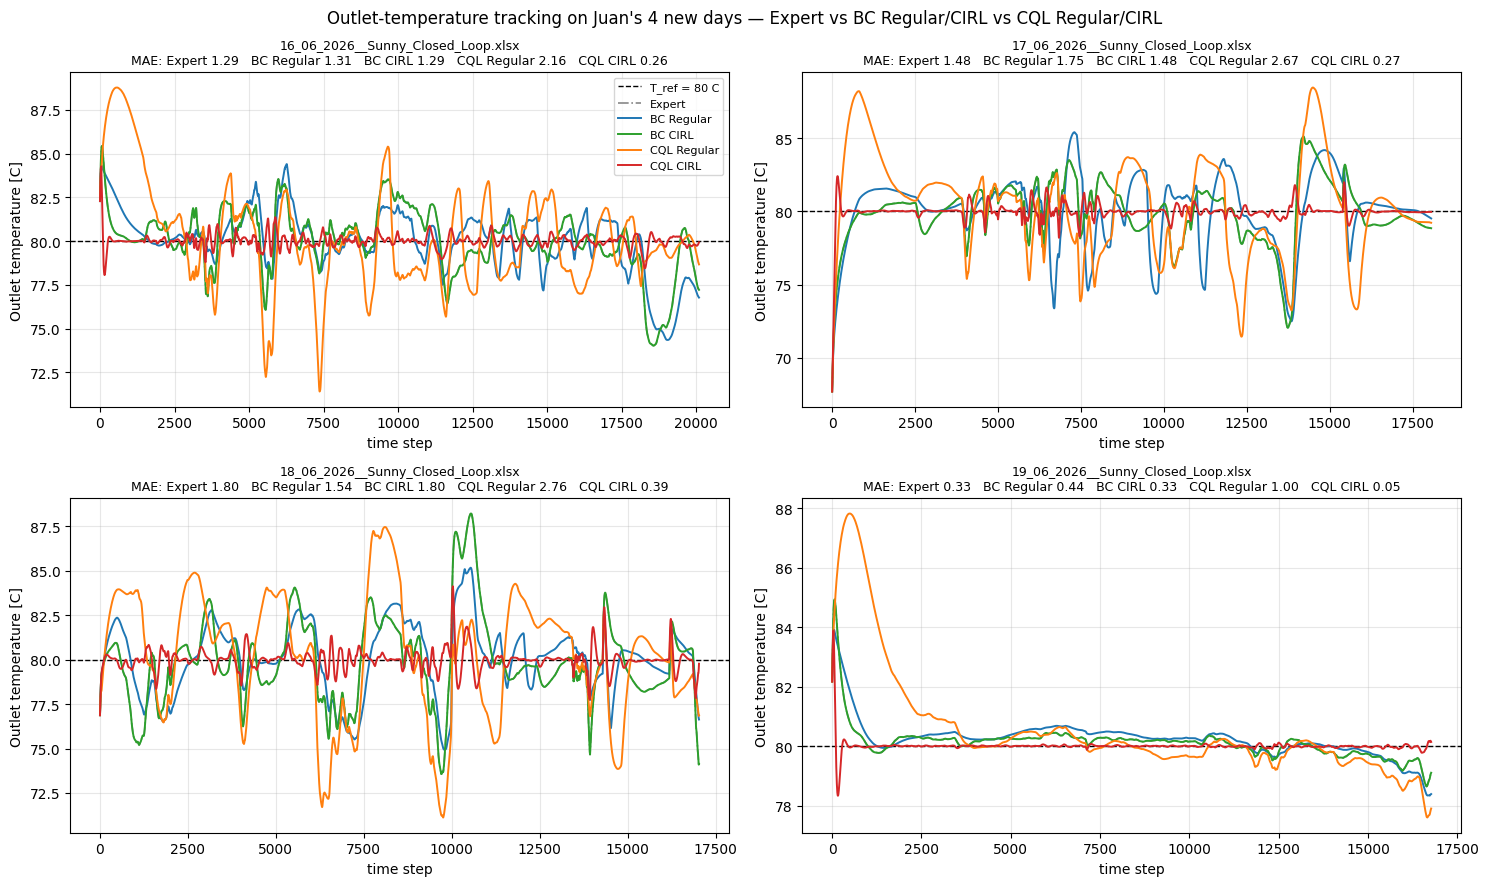

In [4]:
# ── Outlet-temperature tracking on all 4 Juan days, all 5 controllers ───────
COLORS = {'Expert': '#888888', 'BC Regular': '#1f77b4', 'BC CIRL': '#2ca02c',
          'CQL Regular': '#ff7f0e', 'CQL CIRL': '#d62728'}
STYLES = {'Expert': '-.'}

fig, axes = plt.subplots(2, 2, figsize=(15, 9))
for i, ds in enumerate(datasets):
    ax = axes[i // 2, i % 2]
    tr = dataset_tref(ds['name'])
    t = np.arange(len(store['BC Regular'][i]['Tout']))
    ax.axhline(tr, ls='--', c='k', lw=1, label=f'T_ref = {tr:.0f} C')
    maes = {}
    for name in POLICIES:
        Tout = store[name][i]['Tout']
        maes[name] = mae_rmse(Tout, tr)[0]
        ax.plot(t, Tout[:len(t)], c=COLORS[name], ls=STYLES.get(name, '-'),
                lw=1.2 if name == 'Expert' else 1.4, label=name)
    title = '   '.join(f'{n} {maes[n]:.2f}' for n in POLICIES)
    ax.set_title(f"{ds['name']}\nMAE: {title}", fontsize=9)
    ax.set_ylabel('Outlet temperature [C]'); ax.set_xlabel('time step'); ax.grid(alpha=.3)
    if i == 0:
        ax.legend(fontsize=8)
fig.suptitle("Outlet-temperature tracking on Juan's 4 new days — Expert vs BC Regular/CIRL vs CQL Regular/CIRL", fontsize=12)
fig.tight_layout()
fig.savefig(os.path.join(CHART_DIR, 'four_way_offline_comparison_tracking_4days.png'), dpi=150)
plt.show()

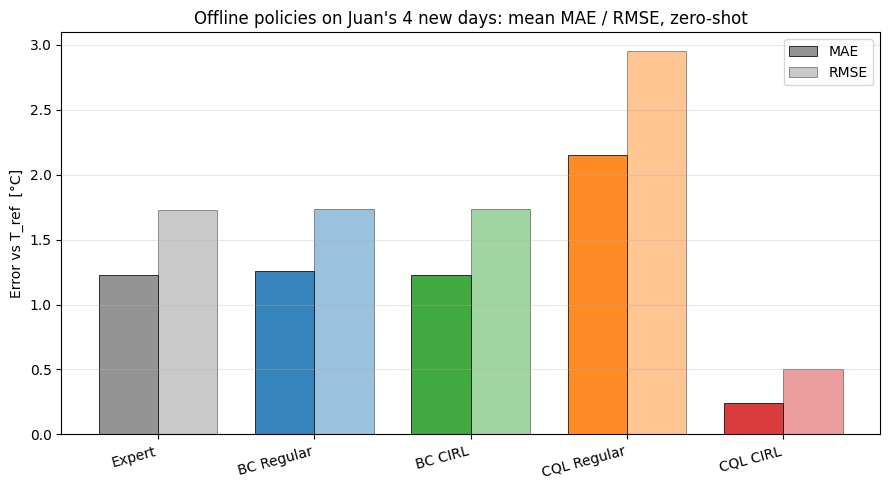

controller       MAE    RMSE
Expert         1.224   1.731
BC Regular     1.261   1.731
BC CIRL        1.224   1.731
CQL Regular    2.149   2.947
CQL CIRL       0.243   0.501


In [5]:
# ── MAE & RMSE bar chart, all four policies + Expert PI reference ──────────
mae_by = {name: np.mean([mae_rmse(store[name][i]['Tout'], dataset_tref(datasets[i]['name']))[0]
                          for i in range(len(datasets))]) for name in POLICIES}
rmse_by = {name: np.mean([mae_rmse(store[name][i]['Tout'], dataset_tref(datasets[i]['name']))[1]
                           for i in range(len(datasets))]) for name in POLICIES}

x = np.arange(len(POLICIES)); w = 0.38
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - w/2, [mae_by[n] for n in POLICIES],  width=w, label='MAE',
       color=[COLORS[n] for n in POLICIES], alpha=0.9, edgecolor='black', linewidth=0.6)
ax.bar(x + w/2, [rmse_by[n] for n in POLICIES], width=w, label='RMSE',
       color=[COLORS[n] for n in POLICIES], alpha=0.45, edgecolor='black', linewidth=0.6)
ax.set_xticks(x); ax.set_xticklabels(POLICIES, rotation=15, ha='right')
ax.set_ylabel('Error vs T_ref  [\u00b0C]')
ax.set_title("Offline policies on Juan's 4 new days: mean MAE / RMSE, zero-shot")
ax.legend(); ax.grid(axis='y', alpha=0.3)
fig.tight_layout()
fig.savefig(os.path.join(CHART_DIR, 'four_way_offline_comparison_bars.png'), dpi=150)
plt.show()

print(f"{'controller':12s} {'MAE':>7} {'RMSE':>7}")
for n in POLICIES:
    print(f"{n:12s} {mae_by[n]:7.3f} {rmse_by[n]:7.3f}")

## What this shows

- **Regular vs CIRL, within each method**: the free-form (Regular) actors and
  the PI-structured (CIRL) actors were trained on identical data, so any gap
  between them isolates the effect of the CIRL structural prior alone,
  independent of the BC/CQL objective.
- **BC vs CQL, within each parameterisation**: both BC actors clone the expert
  and therefore cannot exceed it zero-shot; both CQL actors optimise a learned
  (conservative) value function and are free to exceed it.
- Together the four numbers separate two independent design choices —
  **objective** (imitate vs. optimise a value function) and
  **parameterisation** (free-form flow vs. structured PI gains) — that the
  original two-policy comparison could not disentangle on its own.